# Homework II

## Setup

In [15]:
import glob
import math
import sys
from pathlib import Path
import importlib.util
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

import torch.nn.functional as F
from tqdm.auto import tqdm

### SETUP PATH ###
WORK_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-II') # Current workdir
MAYO_DATASET_PATH = Path('/content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Mayo')

### PARAMETERS ###
NOISE_LEVEL = 0.01
EPOCHS = 3 # Epochs' number


# 1. Trova la cartella IPPy in modo intelligente e sicuro
here = WORK_DIR
for base in (here, *here.parents):
    if (base / 'IPPy').exists():
        # 2. Inietta il percorso ASSOLUTO (non '..') nel sistema
        sys.path.append(str(base))
        break
else:
    raise FileNotFoundError("Impossibile trovare la cartella IPPy. Controlla di averla scaricata.")

# 3. Ora l'importazione standard funzionerà sempre, da qualunque cartella tu avvii il codice
from IPPy import operators, utilities

weights_dir = WORK_DIR / 'weights'
weights_dir.mkdir(exist_ok=True)

device = utilities.get_device()
torch.manual_seed(0)

print('Working device:', device)
print('Weights directory:', weights_dir)

Working device: cuda
Weights directory: /content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-II/weights


## Data Pipeline and Synthetic Measurements

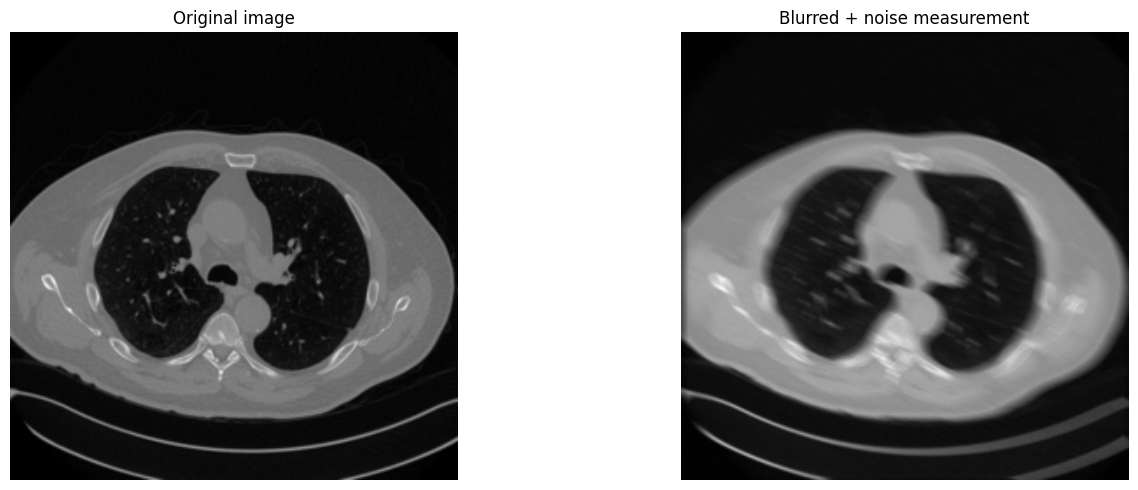

Measurement tensor shape: (1, 1, 256, 256)
Training dataset size: 3306
Test dataset size: 327


In [16]:
def gaussian_noise(y, noise_level):
    e = torch.randn_like(y, device=y.device)
    return e / torch.norm(e) * torch.norm(y) * noise_level

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()
        self.data_path = data_path
        self.data_shape = data_shape
        self.fname_list = glob.glob(f'{data_path}/*/*.png')

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        x = Image.open(img_path).convert('L')
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape),
            #transforms.Resize((256, 256))
        ])(x)
        return x

#torch.manual_seed(0)
device = utilities.get_device()

train_dataset = MayoDataset(data_path=str(MAYO_DATASET_PATH / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(MAYO_DATASET_PATH / 'test'), data_shape=256)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# x_true -> GT (Ground Truth)
x_true = next(iter(train_loader))[0:1].to(device) # 8 img. batch, select just one (first)
K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

with torch.no_grad():
    y_clean = K(x_true) # Blur motion
    y_delta = y_clean + gaussian_noise(y_clean, NOISE_LEVEL) # Blur motion + noise (gaussian noise)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, image, title in zip(
    axes,
    [x_true, y_delta],
    ['Original image', 'Blurred + noise measurement'],
):
    ax.imshow(image.detach().cpu().squeeze(), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

print('Measurement tensor shape:', tuple(y_delta.shape))
print('Training dataset size:', len(train_dataset))
print('Test dataset size:', len(test_dataset))

## Reconstruction Networks & Training, Saving, and Evaluating the Models

### SimpleCNN

Epoch 1/3:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 1: training loss = 0.002328


Epoch 2/3:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 2: training loss = 0.000826


Epoch 3/3:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 3: training loss = 0.000712
Saved SimpleCNN weights to: /content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-II/weights/CNN.pth


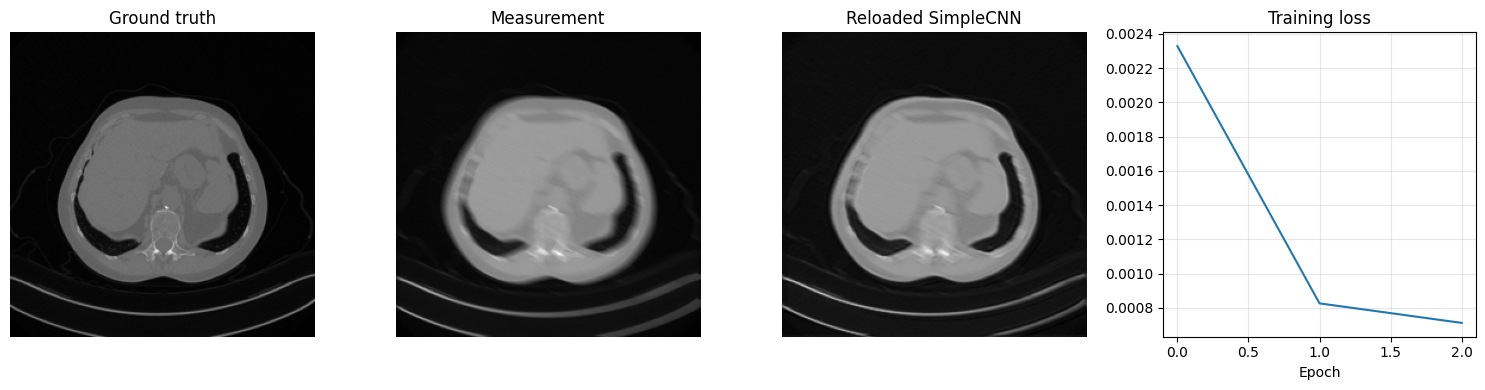

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()

        # Define (convolution) layers -> NOTE: padding="same" means "padded convolution"
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.conv3(h)
        return out

model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = EPOCHS
noise_level = NOISE_LEVEL
history = []
weights_path = weights_dir / 'CNN.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)
    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)

        with torch.no_grad():
            y_batch = K(x_batch)
            y_batch = y_batch + gaussian_noise(y_batch, noise_level=noise_level)

        prediction = model(y_batch)
        loss = loss_fn(prediction, x_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

    history.append(epoch_loss / len(train_loader))
    print(f'Epoch {epoch + 1}: training loss = {history[-1]:.6f}')

torch.save(model.state_dict(), weights_path)
print(f'Saved SimpleCNN weights to: {weights_path}')

reloaded_model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model = reloaded_model.to(device)
reloaded_model.eval()

with torch.no_grad():
    x_test = next(iter(test_loader))[0:1].to(device)
    y_test = K(x_test)
    y_test = y_test + gaussian_noise(y_test, noise_level=noise_level)
    x_pred = reloaded_model(y_test)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_test.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_test.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_pred.cpu().squeeze(), cmap='gray')
plt.title('Reloaded SimpleCNN')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ResCNN

Epoch 1/3:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/414 [00:00<?, ?it/s]

Saved ResCNN weights to: /content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-II/weights/ResCNN.pth


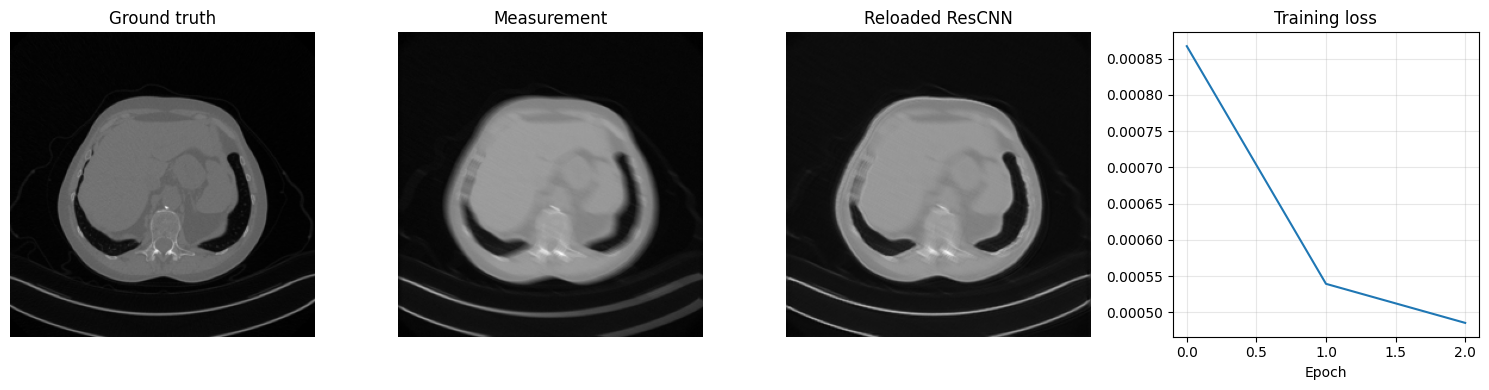

In [ ]:
class ResCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()

        # Define (convolution) layers -> NOTE: padding="same" means "padded convolution"
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.tanh(self.conv3(h))
        return out + x

model = ResCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = EPOCHS
noise_level = NOISE_LEVEL
history = []
weights_path = weights_dir / 'ResCNN.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)

    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)

        with torch.no_grad():
            y_batch = K(x_batch)
            y_batch = y_batch + gaussian_noise(y_batch, noise_level=noise_level)

        prediction = model(y_batch)
        loss = loss_fn(prediction, x_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

    history.append(epoch_loss / len(train_loader))

torch.save(model.state_dict(), weights_path)
print(f'Saved ResCNN weights to: {weights_path}')

reloaded_model = ResCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model = reloaded_model.to(device)
reloaded_model.eval()

with torch.no_grad():
    x_true = next(iter(test_loader))[0:1].to(device)
    y_delta = K(x_true)
    y_delta = y_delta + gaussian_noise(y_delta, noise_level=noise_level)
    x_rec = reloaded_model(y_delta)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title('Reloaded ResCNN')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Visual and Quantitative Comparison

SimpleCNN trainable parameters: 9857
ResCNN trainable parameters: 9857


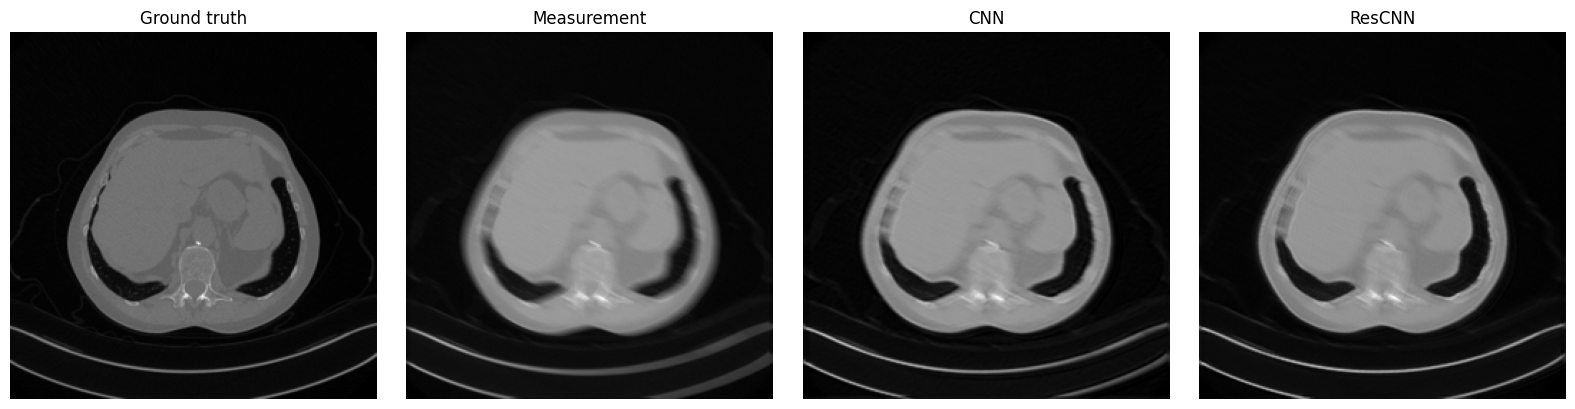

Average metrics over 8 test images
             CNN | MSE: 0.000451 | PSNR: 33.465 dB | SSIM: 0.9151
          ResCNN | MSE: 0.000298 | PSNR: 35.296 dB | SSIM: 0.9316


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding='same')
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding='same')
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding='same')
        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        return self.conv3(h)


class ResCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding='same')
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding='same')
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding='same')
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        return self.tanh(self.conv3(h)) + x

def count_trainable_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)


cnn_model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32)
rescnn_model = ResCNN(in_ch=1, out_ch=1, n_filters=32)

print(f"SimpleCNN trainable parameters: {count_trainable_parameters(cnn_model)}")
print(f"ResCNN trainable parameters: {count_trainable_parameters(rescnn_model)}")


def try_load_model(name, model, filename):
    path = weights_dir / filename
    if not path.exists():
        print(f'Skipping {name}: {path.name} not found.')
        return None
    model.load_state_dict(torch.load(path, map_location='cpu', weights_only=True))
    model = model.to(device)
    model.eval()
    return model


models = {
    'CNN': try_load_model('CNN', SimpleCNN(in_ch=1, out_ch=1, n_filters=32), 'CNN.pth'),
    'ResCNN': try_load_model('ResCNN', ResCNN(in_ch=1, out_ch=1, n_filters=32), 'ResCNN.pth'),
}
models = {name: model for name, model in models.items() if model is not None}

results = {name: {'MSE': [], 'PSNR': [], 'SSIM': []} for name in models}
noise_level = NOISE_LEVEL
num_eval = 8
visual_data = None

torch.manual_seed(123)
for idx in range(num_eval):
    x_true = test_dataset[idx].unsqueeze(0).to(device)
    with torch.no_grad():
        y_delta = K(x_true)
        y_delta = y_delta + gaussian_noise(y_delta, noise_level=noise_level)
        reconstructions = {name: model(y_delta).clamp(0.0, 1.0) for name, model in models.items()}

    x_true_np = x_true.squeeze().cpu().numpy()
    y_delta_np = y_delta.squeeze().cpu().numpy()

    if visual_data is None:
        visual_data = {
            'x_true': x_true_np,
            'y_delta': y_delta_np,
            'recons': {name: rec.squeeze().cpu().numpy() for name, rec in reconstructions.items()},
        }

    for name, rec in reconstructions.items():
        rec_np = rec.squeeze().cpu().numpy()
        mse_val = float(np.mean((rec_np - x_true_np) ** 2))
        psnr_val = peak_signal_noise_ratio(x_true_np, rec_np, data_range=1.0)
        ssim_val = structural_similarity(x_true_np, rec_np, data_range=1.0)

        results[name]['MSE'].append(mse_val)
        results[name]['PSNR'].append(psnr_val)
        results[name]['SSIM'].append(ssim_val)

images = [visual_data['x_true'], visual_data['y_delta']] + [visual_data['recons'][name] for name in models]
titles = ['Ground truth', 'Measurement'] + list(models.keys())
#ncols = 3
ncols = 4
nrows = math.ceil(len(images) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).reshape(nrows, ncols)
for ax, image, title in zip(axes.flat, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
for ax in axes.flat[len(images):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Average metrics over {num_eval} test images')
for name in models:
    mse_mean = np.mean(results[name]['MSE'])
    psnr_mean = np.mean(results[name]['PSNR'])
    ssim_mean = np.mean(results[name]['SSIM'])
    line = f"{name:>16} | MSE: {mse_mean:.6f} | PSNR: {psnr_mean:.3f} dB | SSIM: {ssim_mean:.4f}"
    print(line)

### Versione pulita

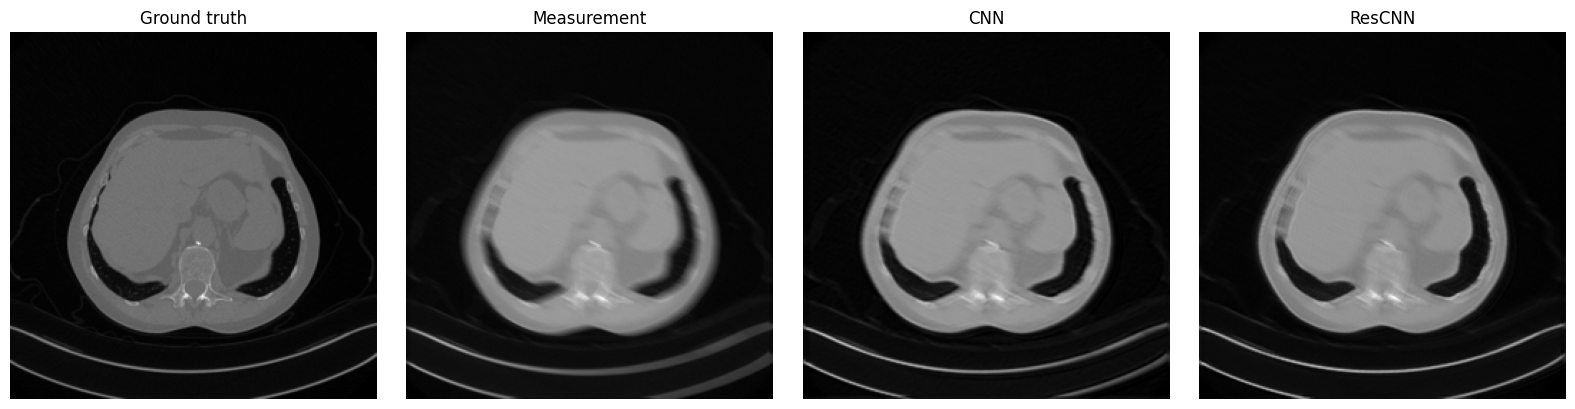

Average metrics over 8 test images
     Measurement | MSE: 0.001020 | PSNR: 29.936 dB | SSIM: 0.8795
             CNN | MSE: 0.000451 | PSNR: 33.465 dB | SSIM: 0.9151
          ResCNN | MSE: 0.000298 | PSNR: 35.296 dB | SSIM: 0.9316


In [ ]:
# Final visual and quantitative comparison

def try_load_model(name, model, filename):
    path = weights_dir / filename
    if not path.exists():
        print(f"Skipping {name}: {path.name} not found.")
        return None

    model.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
    model = model.to(device)
    model.eval()
    return model


models = {
    "CNN": try_load_model(
        "CNN",
        SimpleCNN(in_ch=1, out_ch=1, n_filters=32),
        "CNN.pth",
    ),
    "ResCNN": try_load_model(
        "ResCNN",
        ResCNN(in_ch=1, out_ch=1, n_filters=32),
        "ResCNN.pth",
    ),
}

models = {name: model for name, model in models.items() if model is not None}

results = {
    "Measurement": {"MSE": [], "PSNR": [], "SSIM": []},
}
for name in models:
    results[name] = {"MSE": [], "PSNR": [], "SSIM": []}


num_eval = 8
noise_level = NOISE_LEVEL
visual_data = None

torch.manual_seed(123)

for idx in range(num_eval):
    x_true = test_dataset[idx].unsqueeze(0).to(device)

    with torch.no_grad():
        y_delta = K(x_true)
        y_delta = y_delta + gaussian_noise(y_delta, noise_level=noise_level)

        reconstructions = {
            name: model(y_delta).clamp(0.0, 1.0)
            for name, model in models.items()
        }

    x_true_np = x_true.squeeze().cpu().numpy()
    y_delta_np = y_delta.squeeze().cpu().numpy()

    if visual_data is None:
        visual_data = {
            "x_true": x_true_np,
            "y_delta": y_delta_np,
            "recons": {
                name: rec.squeeze().cpu().numpy()
                for name, rec in reconstructions.items()
            },
        }

    # Metrics for corrupted measurement
    results["Measurement"]["MSE"].append(float(np.mean((y_delta_np - x_true_np) ** 2)))
    results["Measurement"]["PSNR"].append(
        peak_signal_noise_ratio(x_true_np, y_delta_np, data_range=1.0)
    )
    results["Measurement"]["SSIM"].append(
        structural_similarity(x_true_np, y_delta_np, data_range=1.0)
    )

    # Metrics for models
    for name, rec in reconstructions.items():
        rec_np = rec.squeeze().cpu().numpy()

        results[name]["MSE"].append(float(np.mean((rec_np - x_true_np) ** 2)))
        results[name]["PSNR"].append(
            peak_signal_noise_ratio(x_true_np, rec_np, data_range=1.0)
        )
        results[name]["SSIM"].append(
            structural_similarity(x_true_np, rec_np, data_range=1.0)
        )


images = [visual_data["x_true"], visual_data["y_delta"]]
titles = ["Ground truth", "Measurement"]

for name in models:
    images.append(visual_data["recons"][name])
    titles.append(name)

ncols = len(images)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

if ncols == 1:
    axes = [axes]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


print(f"Average metrics over {num_eval} test images")
for name, values in results.items():
    mse_mean = np.mean(values["MSE"])
    psnr_mean = np.mean(values["PSNR"])
    ssim_mean = np.mean(values["SSIM"])

    print(
        f"{name:>16} | "
        f"MSE: {mse_mean:.6f} | "
        f"PSNR: {psnr_mean:.3f} dB | "
        f"SSIM: {ssim_mean:.4f}"
    )

## Deliverables and Discussion

**Discussione Finale**

Nel mio esperimento il modello che ha ottenuto i risultati migliori è stato `ResCNN`. Rispetto alla `SimpleCNN`, la rete residuale ha prodotto un MSE più basso e valori più alti di PSNR e SSIM. Questo comportamento è coerente con l’idea del residual learning: invece di imparare direttamente tutta la ricostruzione da zero, il modello deve imparare una correzione da aggiungere all’immagine corrotta.

L’architettura residuale ha quindi aiutato perché la misura degradata contiene ancora molta informazione strutturale dell’immagine originale. La rete può conservare ciò che è già utile e concentrarsi sulla rimozione del blur e del rumore. Questo rende il problema di apprendimento più semplice rispetto alla predizione diretta dell’intera immagine.

Il livello di rumore influenza sia il training sia la qualità finale della ricostruzione. Con un rumore moderato, come `NOISE_LEVEL = 0.01`, i modelli riescono a imparare una mappatura stabile dalla misura corrotta all’immagine pulita. Se il rumore aumentasse, il problema diventerebbe più difficile: le misure conterrebbero meno informazione affidabile, le immagini ricostruite tenderebbero a essere più lisce e le metriche quantitative peggiorerebbero.

È importante generare la corruzione tramite un operatore noto `K` perché il problema non è un generico image-to-image task, ma un problema inverso. Conoscere il modello diretto permette di controllare esattamente come vengono generate le misure, confrontare i modelli in modo equo e mantenere un legame con la fisica del processo di acquisizione.

Bisogna essere cauti nel valutare metodi end-to-end solo tramite qualità visiva. Una ricostruzione può sembrare gradevole ma non essere fedele all’immagine originale o alla misura osservata. Per questo è utile affiancare al confronto visivo metriche quantitative come MSE, PSNR e SSIM, e ricordare sempre il ruolo dell’operatore diretto e del rumore.